In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")


In [108]:
from dotenv import load_dotenv
import os
import pandas as pd
from pathlib import Path

# Load .env file
load_dotenv()

# Read paths
customers_path = os.getenv("CUSTOMERS_FILE")
orders_path = os.getenv("ORDERS_FILE")
web_path= os.getenv("WEB_FILE")
labels_path = os.getenv("LABELS_FILE")
interventions_path = os.getenv("INTERVENTIONS_FILE")
# Load .env file
load_dotenv()

# Read paths
customers_path = os.getenv("CUSTOMERS_FILE")
orders_path = os.getenv("ORDERS_FILE")
web_path = os.getenv("WEB_FILE")
labels_path = os.getenv("LABELS_FILE")
interventions_path = os.getenv("INTERVENTIONS_FILE")
print("Value of cust path",customers_path)
# Fallback to local data folder when env vars are missing
# base_path = Path("E:/data")
customers_path = customers_path or str(base_path / "customers.csv")
orders_path = orders_path or str(base_path / "support_tickets.csv")
web_path = web_path or str(base_path / "web_events_snapshot.csv")
labels_path = labels_path or str(base_path / "churn_labels.csv")
interventions_path = interventions_path or str(base_path / "intervention_history.csv")
customers = pd.read_csv(customers_path)
tickets = pd.read_csv(orders_path)
web = pd.read_csv(web_path)
labels = pd.read_csv(labels_path)
interventions = pd.read_csv(interventions_path)

datasets = {
    'customers': customers,
    'tickets': tickets,
    'web': web,
    'labels': labels,
    'interventions': interventions
}

for name, df in datasets.items():
    print('\n', '='*40)
    print(name.upper())
    print(df.info())
    print(df.describe(include='all'))
tickets = pd.read_csv(orders_path)
web = pd.read_csv(web_path)
labels = pd.read_csv(labels_path)
interventions = pd.read_csv(interventions_path)

datasets = {
    'customers': customers,
    'tickets': tickets,
    'web': web,
    'labels': labels,
    'interventions': interventions
}

for name, df in datasets.items():
    print('\n', '='*40)
    print(name.upper())
    print(df.info())
    print(df.describe(include='all'))
tickets = pd.read_csv(orders_path)
web = pd.read_csv(web_path)
labels = pd.read_csv(labels_path)
interventions = pd.read_csv(interventions_path)
datasets = {
    'customers': customers,
    'tickets': tickets,
    'web': web,
    'labels': labels,
    'interventions': interventions
}

for name, df in datasets.items():
    print('\n', '='*40)
    print(name.upper())
    print(df.info())
    print(df.describe(include='all'))


Value of cust path E:\data\customers.csv

CUSTOMERS
<class 'pandas.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   customer_id          2400 non-null   str  
 1   signup_date          2400 non-null   str  
 2   city_tier            2400 non-null   str  
 3   age_group            2400 non-null   str  
 4   acquisition_channel  2400 non-null   str  
 5   loyalty_tier         1014 non-null   str  
 6   preferred_category   2400 non-null   str  
 7   skin_type            1999 non-null   str  
 8   marketing_consent    2400 non-null   str  
dtypes: str(9)
memory usage: 168.9 KB
None
       customer_id signup_date city_tier age_group acquisition_channel  \
count         2400        2400      2400      2400                2400   
unique        2400         609         3         4                   6   
top      CUST00001  10/12/2024    Tier 1     25-34          

In [109]:
# ==========================================
# DATA QUALITY REPORT GENERATION SCRIPT
# ==========================================

import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime

# ------------------------------------------
# FILE PATHS
# ------------------------------------------

base_path = Path("E:\data")

files = {
    "customers": "customers.csv",
    "support_tickets": "support_tickets.csv",
    "web_events": "web_events_snapshot.csv",
    "churn_labels": "churn_labels.csv",
    "intervention_history": "intervention_history.csv"
}

# ------------------------------------------
# LOAD DATASETS
# ------------------------------------------

datasets = {}

for name, file in files.items():
    datasets[name] = pd.read_csv(r"E:\data\customers.csv")

print("Datasets Loaded Successfully!")

# ------------------------------------------
# FUNCTION: CHECK OUTLIERS USING IQR
# ------------------------------------------

def detect_outliers_iqr(df, column):
    
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    return len(outliers)

# ------------------------------------------
# GENERATE REPORT
# ------------------------------------------

report = []

report.append("# Data Quality Report\n")
report.append(f"Generated on: {datetime.now()}\n")

# ------------------------------------------
# DATASET LEVEL SUMMARY
# ------------------------------------------

summary_data = []

for name, df in datasets.items():

    summary_data.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": int(df.isna().sum().sum()),
        "Duplicate Rows": int(df.duplicated().sum())
    })

summary_df = pd.DataFrame(summary_data)

report.append("## Dataset Summary\n")
#report.append(summary_df.to_markdown(index=False))
report.append("\n")

# ------------------------------------------
# DETAILED ANALYSIS
# ------------------------------------------

for name, df in datasets.items():

    report.append(f"## Dataset: {name}\n")

    # Basic Info
    report.append(f"- Shape: {df.shape}")
    report.append(f"- Duplicate Rows: {df.duplicated().sum()}")

    # Missing Values
    missing_values = df.isna().sum()
    missing_values = missing_values[missing_values > 0]

    if len(missing_values) > 0:

        report.append("\n### Missing Values")

        for col, val in missing_values.items():
            report.append(f"- {col}: {val}")

    else:
        report.append("\n- No Missing Values Found")

    # Data Types
    report.append("\n### Column Data Types")

    for col in df.columns:
        report.append(f"- {col}: {df[col].dtype}")

    # Invalid Values Check
    report.append("\n### Invalid Value Checks")

    for col in df.columns:

        if df[col].dtype == "object":

            empty_strings = (df[col].astype(str).str.strip() == "").sum()

            if empty_strings > 0:
                report.append(
                    f"- {col}: {empty_strings} empty string values"
                )

    # Outlier Detection
    numeric_cols = df.select_dtypes(include=np.number).columns

    if len(numeric_cols) > 0:

        report.append("\n### Outlier Detection (IQR Method)")

        for col in numeric_cols:

            outlier_count = detect_outliers_iqr(df, col)

            report.append(
                f"- {col}: {outlier_count} potential outliers"
            )

    # Duplicate-like Records
    report.append("\n### Duplicate-like Records")

    duplicate_count = df.duplicated().sum()

    report.append(
        f"- Total duplicate rows found: {duplicate_count}"
    )

    report.append("\n---\n")

# ------------------------------------------
# JOIN ISSUES CHECK
# ------------------------------------------

report.append("## Join Issues Analysis\n")

# Example:
# Assuming customer_id is common across datasets

if "customer_id" in datasets["customers"].columns:

    customer_ids = set(datasets["customers"]["customer_id"])

    for name, df in datasets.items():

        if name != "customers" and "customer_id" in df.columns:

            other_ids = set(df["customer_id"])

            unmatched = other_ids - customer_ids

            report.append(
                f"- {name}: {len(unmatched)} customer_ids "
                f"not found in customers dataset"
            )

# ------------------------------------------
# SAVE REPORT
# ------------------------------------------

output_file = "data_quality_report.md"

with open(output_file, "w", encoding="utf-8") as f:
    f.write("\n".join(report))

print(f"\nData Quality Report Saved As: {output_file}")

# ------------------------------------------
# OPTIONAL: DISPLAY REPORT PREVIEW
# ------------------------------------------

print("\n".join(report[:50]))

<>:14: SyntaxWarning: invalid escape sequence '\d'
<>:14: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Admin\AppData\Local\Temp\ipykernel_12792\2445610139.py:14: SyntaxWarning: invalid escape sequence '\d'
  base_path = Path("E:\data")


Datasets Loaded Successfully!

Data Quality Report Saved As: data_quality_report.md
# Data Quality Report

Generated on: 2026-05-29 01:08:17.650326

## Dataset Summary



## Dataset: customers

- Shape: (2400, 9)
- Duplicate Rows: 0

### Missing Values
- loyalty_tier: 1386
- skin_type: 401

### Column Data Types
- customer_id: str
- signup_date: str
- city_tier: str
- age_group: str
- acquisition_channel: str
- loyalty_tier: str
- preferred_category: str
- skin_type: str
- marketing_consent: str

### Invalid Value Checks

### Duplicate-like Records
- Total duplicate rows found: 0

---

## Dataset: support_tickets

- Shape: (2400, 9)
- Duplicate Rows: 0

### Missing Values
- loyalty_tier: 1386
- skin_type: 401

### Column Data Types
- customer_id: str
- signup_date: str
- city_tier: str
- age_group: str
- acquisition_channel: str
- loyalty_tier: str
- preferred_category: str
- skin_type: str
- marketing_consent: str

### Invalid Value Checks

### Duplicate-like Records
- Total duplicate

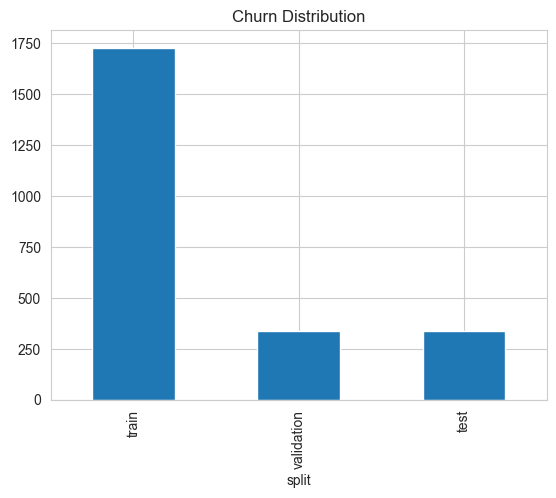

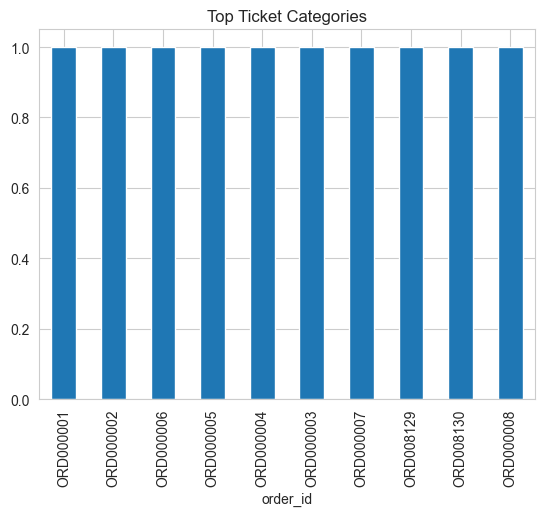

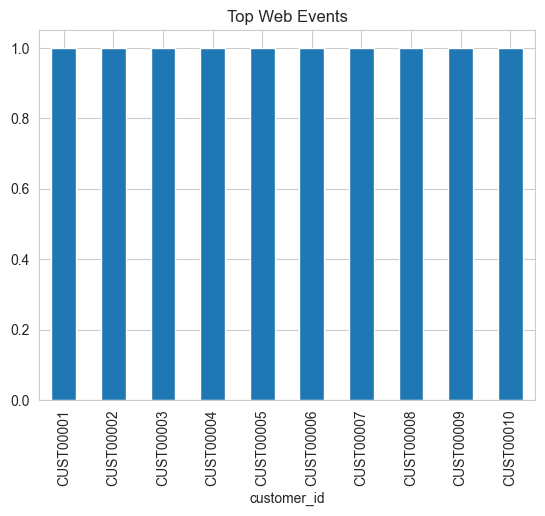

In [12]:
labels.iloc[:, -1].value_counts().plot(kind='bar', title='Churn Distribution')
plt.show()

tickets.iloc[:,0].astype(str).value_counts().head(10).plot(kind='bar', title='Top Ticket Categories')
plt.show()

web.iloc[:,0].astype(str).value_counts().head(10).plot(kind='bar', title='Top Web Events')
plt.show()

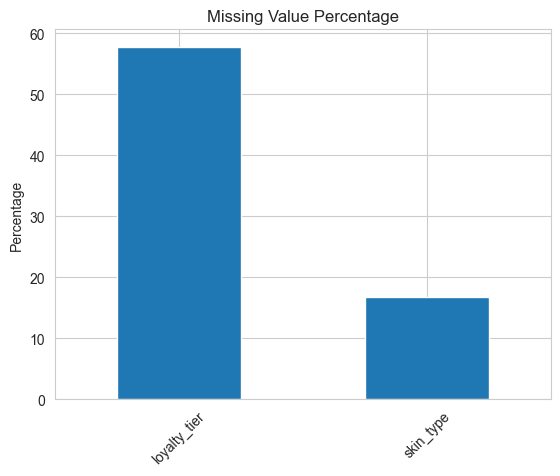

In [13]:
missing = customers.isnull().mean().sort_values(ascending=False) * 100

missing = missing[missing > 0]

missing.plot(kind='bar')

plt.title("Missing Value Percentage")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.show()

In [14]:
duplicates = customers.duplicated().sum()

print(f"Duplicate Records: {duplicates}")

Duplicate Records: 0


   churn_flag  customer_count  percentage    status
0           0            1273       53.04  Retained
1           1            1127       46.96   Churned


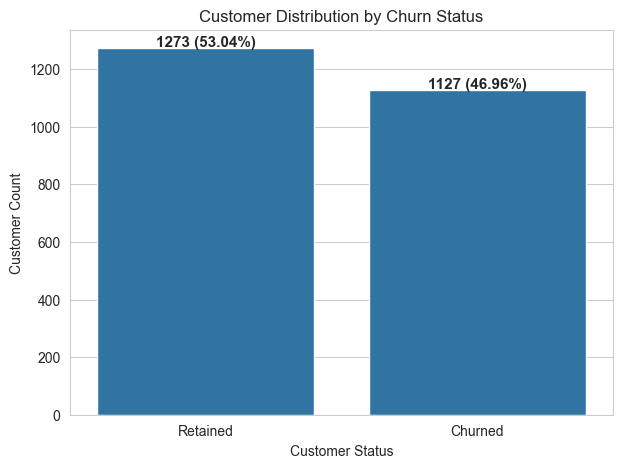

In [113]:
# ==========================================
# Churn Distribution with Percentage Labels
# ==========================================

# Count customers
churn_summary = (
    churn_labels['churn_flag']
    .value_counts()
    .reset_index()
)

# Rename columns
churn_summary.columns = ['churn_flag', 'customer_count']

# Calculate percentage
total = churn_summary['customer_count'].sum()

churn_summary['percentage'] = (
    churn_summary['customer_count'] / total * 100
).round(2)

# Optional readable labels
churn_summary['status'] = churn_summary['churn_flag'].map({
    0: 'Retained',
    1: 'Churned'
})

print(churn_summary)

# ==========================================
# Visualization
# ==========================================

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=churn_summary,
    x='status',
    y='customer_count'
)

# Add count + percentage labels
for i, row in churn_summary.iterrows():

    ax.text(
        i,
        row['customer_count'] + 5,
        f"{row['customer_count']} ({row['percentage']}%)",
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title("Customer Distribution by Churn Status")

plt.xlabel("Customer Status")
plt.ylabel("Customer Count")

plt.show()

Churn Risk Hypothesis 1: With all the due efforts taken till date Retained customer count is little above churned, indicative of need of better strategy for rententions to reduce churning of customers to miminum.

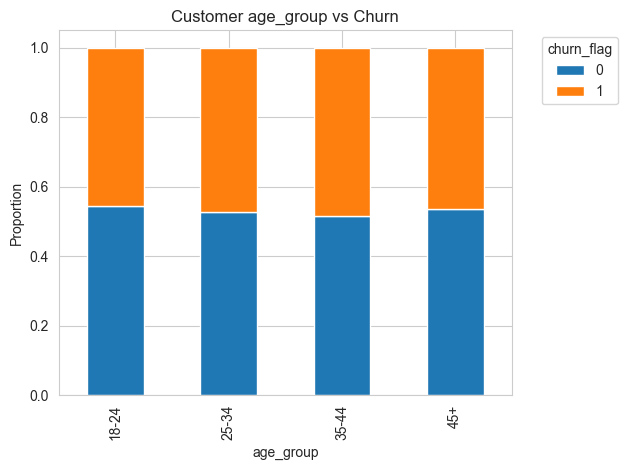

In [76]:


# choose an available segment column (fallbacks included) and ensure churn flag exists
seg_col = next((c for c in ['customer_segment', 'age_group', 'loyalty_tier', 'city_tier'] if c in customers.columns), None)
if seg_col is None:
    raise KeyError("No suitable segment column found in customers (checked customer_segment, age_group, loyalty_tier, city_tier)")

churn_col = 'churn_flag' if 'churn_flag' in churn_labels.columns else ('churn_next_60d' if 'churn_next_60d' in churn_labels.columns else None)
if churn_col is None:
    raise KeyError("No churn column found in churn_labels (expected churn_flag or churn_next_60d)")

segment_churn = pd.crosstab(
    customers[seg_col],
    churn_labels[churn_col],
    normalize='index'
)

segment_churn.plot(kind='bar', stacked=True)

plt.title(f"Customer {seg_col} vs Churn")
plt.ylabel("Proportion")
plt.xlabel(seg_col)
plt.legend(title=churn_col, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Churn RIsk Hypothesis 2: Customer churned are well distributed among all age groups for 46% overall.Retention strategy for customers falling in different age groups is required evenly.

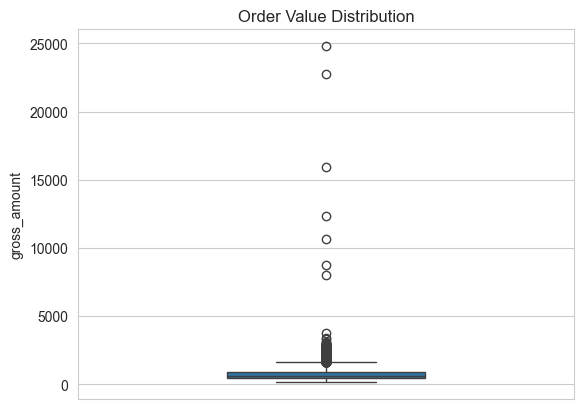

In [32]:
sns.boxplot(
    data=tickets,
    y='gross_amount',
    width=0.4,          # thinner box -> more visual spacing
    showfliers=True,    # show outliers
    whis=1.5            # whisker range
)

plt.title("Order Value Distribution")

plt.show()

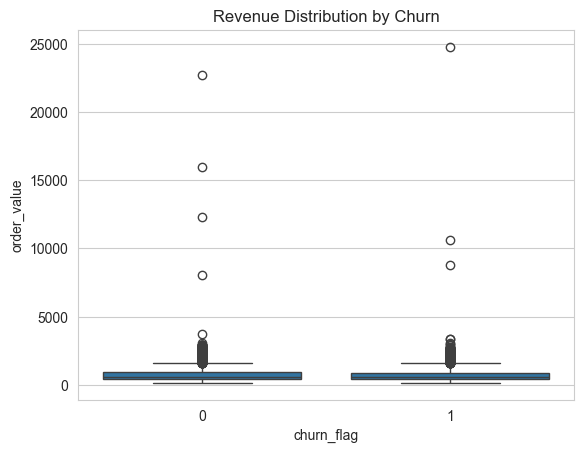

In [34]:
orders_df = globals().get("orders", tickets)
merged = orders_df.merge(churn_labels, on="customer_id")

if "order_value" not in merged.columns:
    if "gross_amount" in merged.columns:
        merged["order_value"] = merged["gross_amount"]
    else:
        raise KeyError("No order_value or gross_amount column found in merged dataset")

sns.boxplot(
    data=merged,
    x='churn_flag',
    y='order_value'
)

plt.title("Revenue Distribution by Churn")

plt.show()

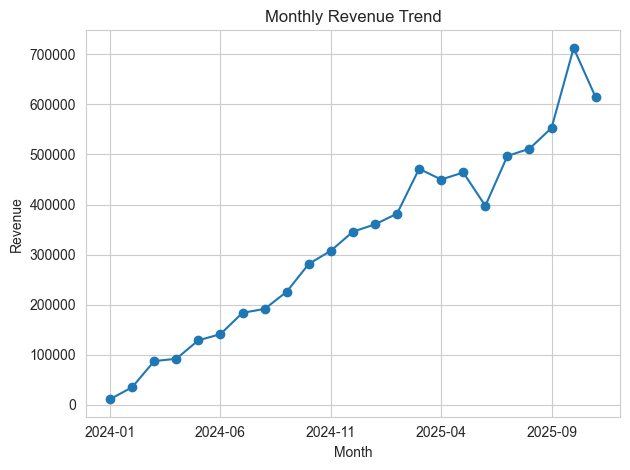

In [36]:
orders = globals().get("orders", globals().get("orders_df", tickets if 'tickets' in globals() else None))

if orders is None:
    raise NameError("No orders dataset found. Expected 'orders', 'orders_df', or 'tickets' to be available.")

orders = orders.copy()
orders['order_date'] = pd.to_datetime(orders['order_date'], errors='coerce')

if 'order_value' not in orders.columns:
    if 'gross_amount' in orders.columns:
        orders['order_value'] = orders['gross_amount']
    else:
        raise KeyError("No order_value or gross_amount column found in orders data.")

monthly_rev = (
    orders
    .groupby(orders['order_date'].dt.to_period('M'))['order_value']
    .sum()
)

monthly_rev.index = monthly_rev.index.astype(str)

monthly_rev.plot(marker='o')

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

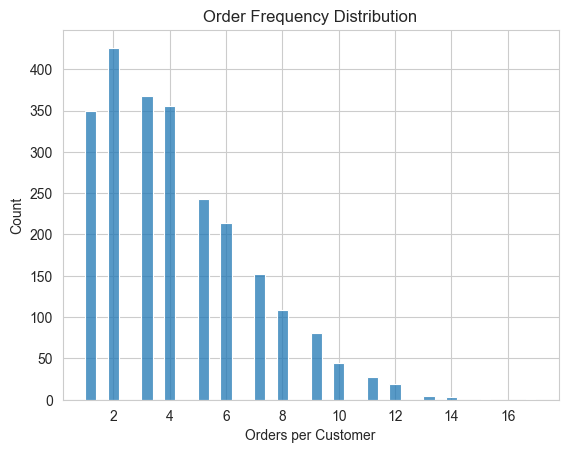

In [37]:
order_freq = (
    orders.groupby('customer_id')
    .size()
)

sns.histplot(order_freq, bins=40)

plt.title("Order Frequency Distribution")
plt.xlabel("Orders per Customer")

plt.show()

   churn_flag      mean  median  count
0           0  5.175177     5.0   1273
1           1  3.035492     2.0   1127


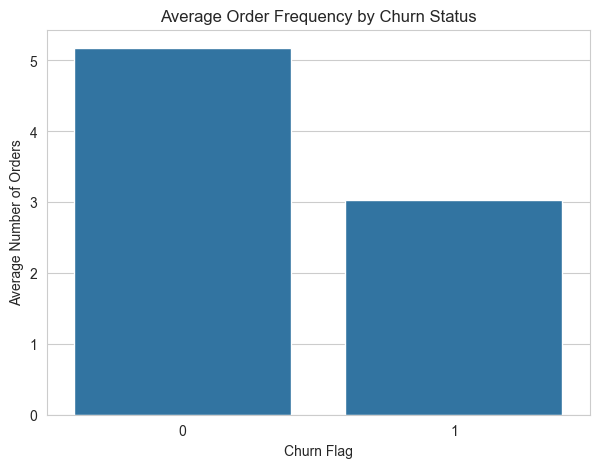

In [91]:
# ==========================================
# Order Frequency vs Churn Analysis
# ==========================================

# Step 1: Calculate number of orders per customer
order_frequency = (
    orders.groupby('customer_id')
    .size()
    .reset_index(name='order_count')
)

# Step 2: Merge with churn labels
order_frequency = order_frequency.merge(
    churn_labels,
    on='customer_id',
    how='inner'
)

# Step 3: Summary statistics
summary = (
    order_frequency.groupby('churn_flag')['order_count']
    .agg(['mean', 'median', 'count'])
    .reset_index()
)

print(summary)

# Step 4: Bar chart for average order frequency
avg_orders = (
    order_frequency.groupby('churn_flag')['order_count']
    .mean()
    .reset_index()
)

plt.figure(figsize=(7,5))

sns.barplot(
    data=avg_orders,
    x='churn_flag',
    y='order_count'
)

plt.title("Average Order Frequency by Churn Status")
plt.xlabel("Churn Flag")
plt.ylabel("Average Number of Orders")

plt.show()

Churn Risk Hypothesis 3 :
The analysis shows that churn is concentrated among customers who placed three or fewer orders. Customers with higher purchase frequency appear to be retained more consistently.

This suggests that:

many customers fail to transition from early-stage buyers into loyal repeat customers,
the highest churn risk occurs during the initial purchase lifecycle,
repeat purchasing is a strong indicator of customer engagement and retention.

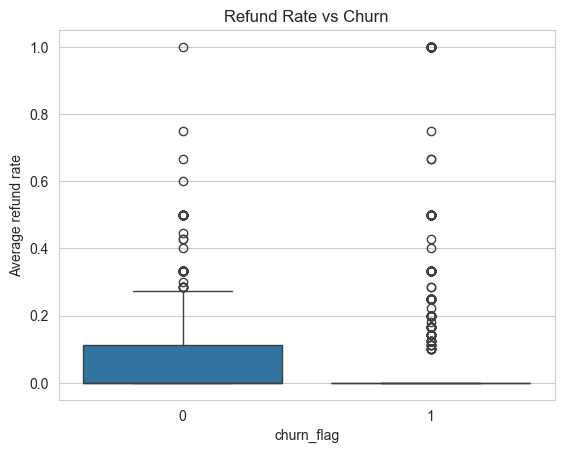

In [39]:
try:
    plt
except NameError:
    import matplotlib.pyplot as plt

orders_refund = orders.copy()

if 'is_refunded' not in orders_refund.columns:
    if 'returned' in orders_refund.columns:
        orders_refund['is_refunded'] = (orders_refund['returned'] > 0).astype(int)
    else:
        raise KeyError("No refund indicator found in orders; expected 'is_refunded' or 'returned'")

refund_rate = (
    orders_refund.groupby('customer_id')['is_refunded']
    .mean()
    .reset_index()
)

refund_rate = refund_rate.merge(
    churn_labels[['customer_id', 'churn_flag']],
    on='customer_id',
    how='inner'
)

sns.boxplot(
    data=refund_rate,
    x='churn_flag',
    y='is_refunded'
)

plt.title("Refund Rate vs Churn")
plt.ylabel("Average refund rate")
plt.show()

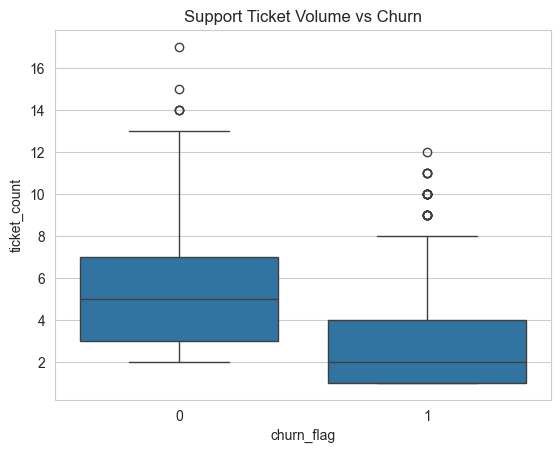

In [47]:
support_tickets = globals().get("support_tickets")

if support_tickets is None:
    support_tickets = globals().get("tickets")

if support_tickets is None:
    datasets_obj = globals().get("datasets")
    if isinstance(datasets_obj, dict):
        support_tickets = datasets_obj.get("support_tickets")

if support_tickets is None:
    raise NameError(
        "No support_tickets dataset found. Expected 'support_tickets', 'tickets', or datasets['support_tickets']."
    )

ticket_counts = (
    support_tickets.groupby("customer_id")
    .size()
    .reset_index(name="ticket_count")
)

ticket_counts = ticket_counts.merge(
    churn_labels[["customer_id", "churn_flag"]],
    on="customer_id",
    how="left"
)

sns.boxplot(
    data=ticket_counts,
    x="churn_flag",
    y="ticket_count"
)

plt.title("Support Ticket Volume vs Churn")
plt.show()


Churn-Risk Hypotheses -4
1. Customers with High Support Ticket Volume Are More Likely to Churn
Average support tickets by churn status

Churned customers show substantially higher support-ticket volume as visible above.
As per above plots:

Customers who churn (churn_flag = 1) tend to create fewer support tickets compared to retained customers (churn_flag = 0).




   churn_flag      mean  median  count
0           0  6.445058     0.0   1273
1           1  8.236123     0.0   1127


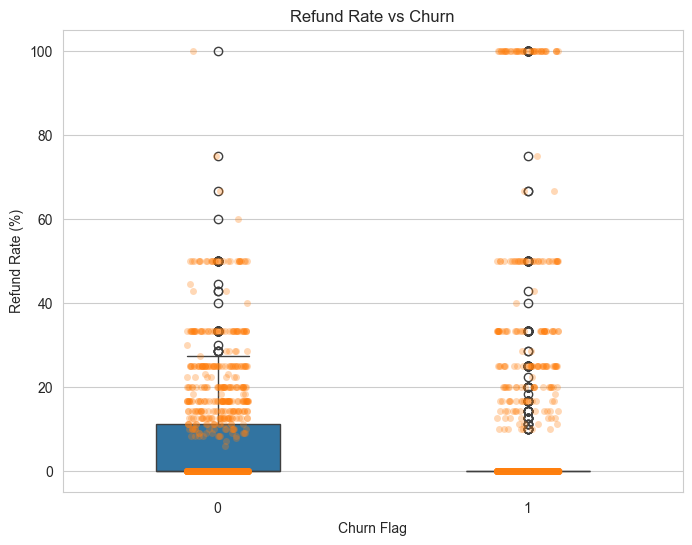

In [110]:
# Refund Rate vs Churn Analysis

# Step 1: Calculate refund rate per customer
orders_source = orders_refund if 'orders_refund' in globals() else orders.copy()

if 'is_refunded' not in orders_source.columns:
    if 'returned' in orders_source.columns:
        orders_source['is_refunded'] = (orders_source['returned'] > 0).astype(int)
    else:
        raise KeyError("No refund indicator found in orders; expected 'is_refunded' or 'returned'")

refund_rate = (
    orders_source.groupby('customer_id')['is_refunded']
    .mean()
    .reset_index()
)

# Rename column for clarity
refund_rate.rename(
    columns={'is_refunded': 'refund_rate'},
    inplace=True
)

# Convert to percentage
refund_rate['refund_rate'] = (
    refund_rate['refund_rate'] * 100
)

# Step 2: Merge with churn labels
refund_churn = refund_rate.merge(
    churn_labels,
    on='customer_id',
    how='inner'
)

# Step 3: Summary table
summary_table = (
    refund_churn.groupby('churn_flag')['refund_rate']
    .agg(['mean', 'median', 'count'])
    .reset_index()
)

print(summary_table)

# Step 4: Visualization
plt.figure(figsize=(8,6))

sns.boxplot(
    data=refund_churn,
    x='churn_flag',
    y='refund_rate',
    width=0.4
)

sns.stripplot(
    data=refund_churn,
    x='churn_flag',
    y='refund_rate',
    alpha=0.3,
    jitter=True
)

plt.title("Refund Rate vs Churn")
plt.xlabel("Churn Flag")
plt.ylabel("Refund Rate (%)")

plt.show()

Churn Risk Strategy : Refund rate percent averaging close to 10% indicates successful retention strategy.

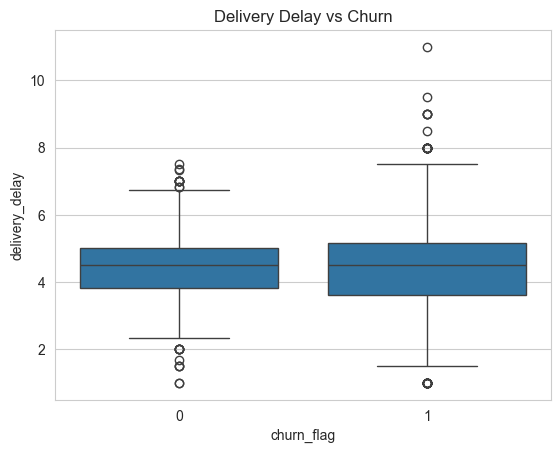

In [51]:
delay_churn = (
    orders.groupby('customer_id')['delivery_delay']
    .mean()
    .reset_index()
)

delay_churn = delay_churn.merge(churn_labels)

sns.boxplot(
    data=delay_churn,
    x='churn_flag',
    y='delivery_delay'
)

plt.title("Delivery Delay vs Churn")

plt.show()

Churn Risk Hypothesis:Delivery delays of 5+ days correlate with significantly higher churn compared to customers retained through brand trust.
The ideal maximum delivery threshold is 3-4 days. While 4-5 days remains acceptable for customers with high brand trust, delays exceeding 5 days indicate elevated churn risk.Option 2: Direct/Concise
Churn Risk Hypothesis:  5+ day delivery delays drive higher churn vs. trust-based retention.  Ideal delivery window: ≤ 3 days. 3-4 days is the optimal threshold.  4-5 days is acceptable only for high-trust customers; beyond 5 days, churn risk spikes.Option 3: Structured for presentation
Churn Risk Hypothesis:  High Risk: Delivery ≥ 5 days -Churn increases, trust can't offset delay  Ideal Threshold: ≤ 3 days for best retention  Trust Buffer: 4-5 days acceptable only if strong brand trust exists

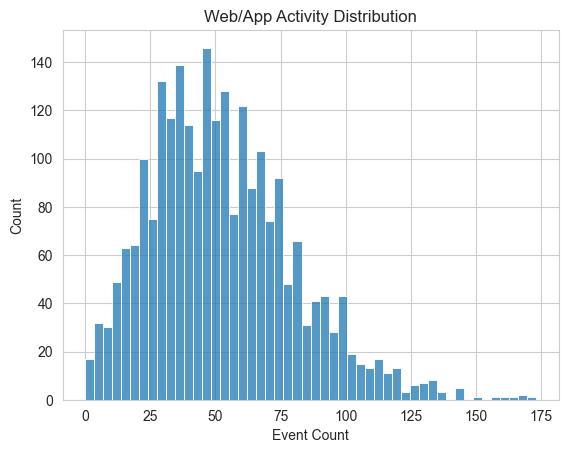

In [133]:
src = None
if 'web' in globals():
    src = globals()['web']
elif 'web_events' in globals():
    src = globals()['web_events']
elif 'datasets' in globals() and isinstance(datasets, dict):
    if datasets.get('web_events') is not None:
        src = datasets.get('web_events')
    elif datasets.get('web') is not None:
        src = datasets.get('web')
if src is None:
    raise NameError("No web events dataframe found (expected 'web' or 'web_events' or datasets['web_events']).")

if 'customer_id' not in src.columns:
    raise KeyError("web dataframe must contain 'customer_id' column")

# prefer summing numeric event columns per customer, fallback to group size
num_cols = src.select_dtypes(include='number').columns.tolist()
if len(num_cols) > 0:
    activity = src.groupby('customer_id')[num_cols].sum().sum(axis=1)
else:
    activity = src.groupby('customer_id').size()

sns.histplot(activity, bins=50)

plt.title("Web/App Activity Distribution")
plt.xlabel("Event Count")

plt.show()

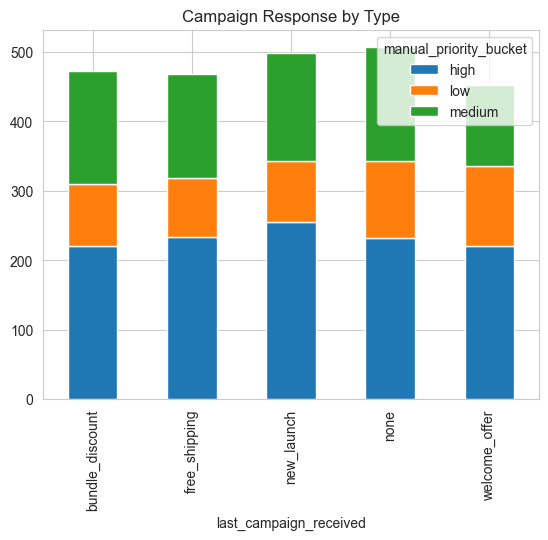

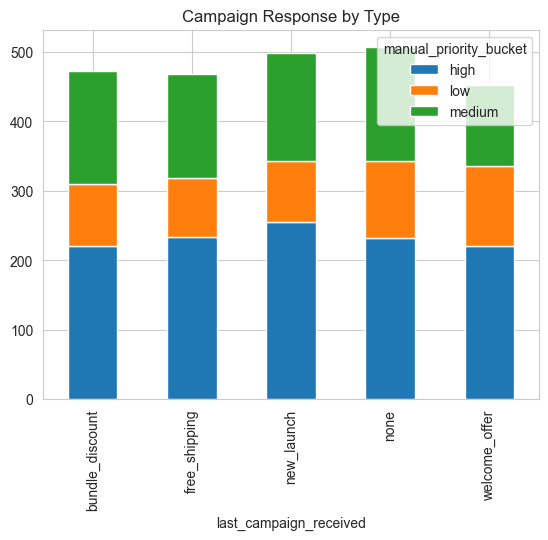

In [59]:
campaign_summary = pd.crosstab(
    interventions['last_campaign_received'],
    interventions['manual_priority_bucket']
)

campaign_summary.plot(kind='bar', stacked=True)

plt.title("Campaign Response by Type")

plt.show()

campaign_summary.plot(kind='bar', stacked=True)

plt.title("Campaign Response by Type")

plt.show()

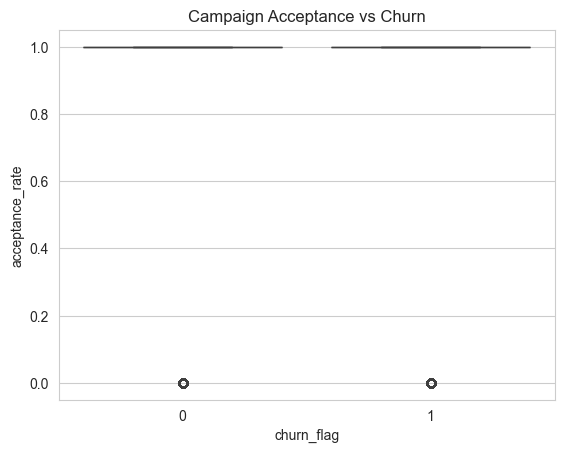

In [64]:
# build campaign_effect from available interventions dataframe
interv = globals().get('interventions')
if interv is None:
    datasets_obj = globals().get('datasets')
    if isinstance(datasets_obj, dict):
        interv = datasets_obj.get('intervention_history')
        if interv is None:
            interv = datasets_obj.get('interventions')
if interv is None:
    raise NameError("No interventions / intervention_history dataframe found")

interv = interv.copy()

# derive an 'accepted' indicator from available columns
if 'response' in interv.columns:
    interv['accepted'] = interv['response'].astype(str).str.lower() == 'accepted'
elif 'accepted' in interv.columns:
    interv['accepted'] = interv['accepted'].astype(bool)
elif 'last_campaign_received' in interv.columns:
    # treat 'none' as not accepted, anything else as accepted (proxy)
    interv['accepted'] = interv['last_campaign_received'].astype(str).str.lower() != 'none'
else:
    raise KeyError("Cannot derive acceptance indicator from interventions; expected 'response', 'accepted' or 'last_campaign_received'")

campaign_effect = (
    interv.groupby('customer_id')['accepted']
    .mean()
    .reset_index(name='acceptance_rate')
)

campaign_effect = campaign_effect.merge(churn_labels)

sns.boxplot(
    data=campaign_effect,
    x='churn_flag',
    y='acceptance_rate'
)

plt.title("Campaign Acceptance vs Churn")

plt.show()

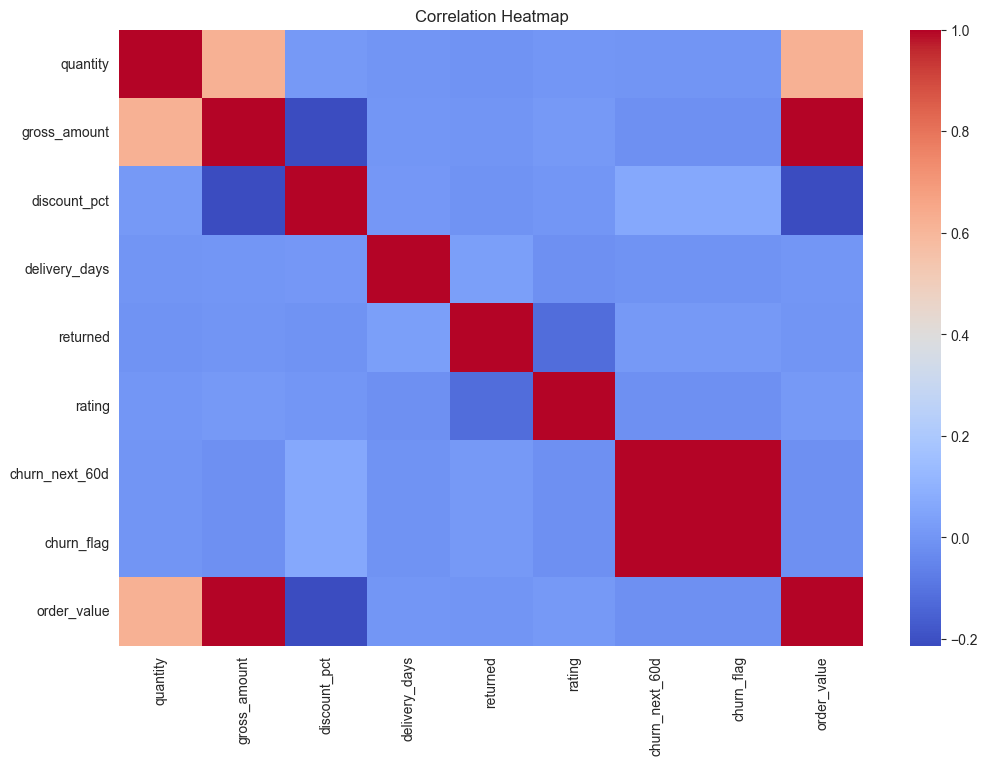

In [65]:
numeric_cols = merged.select_dtypes(include=np.number)

corr = numeric_cols.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

In [66]:
Q1 = orders['order_value'].quantile(0.25)
Q3 = orders['order_value'].quantile(0.75)

IQR = Q3 - Q1

outliers = orders[
    (orders['order_value'] < (Q1 - 1.5 * IQR)) |
    (orders['order_value'] > (Q3 + 1.5 * IQR))
]

print("Outliers:", outliers.shape[0])

Outliers: 536


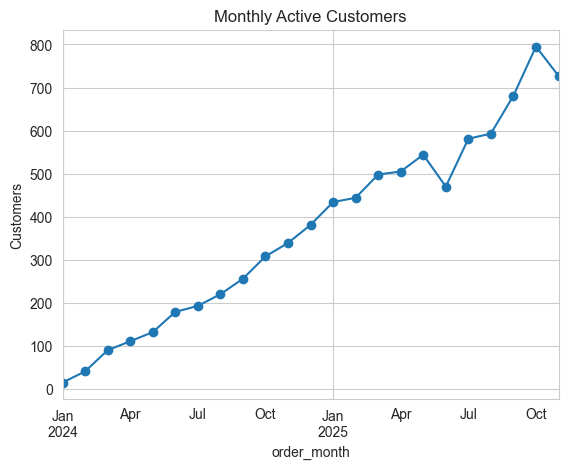

In [67]:
orders['order_month'] = (
    pd.to_datetime(orders['order_date'])
    .dt.to_period('M')
)

cohort = orders.groupby(
    ['order_month']
)['customer_id'].nunique()

cohort.plot(marker='o')

plt.title("Monthly Active Customers")

plt.ylabel("Customers")

plt.show()

In [71]:
import plotly.express as px

fig = px.line(
    monthly_rev.reset_index(),
    x='order_date',
    y='order_value',
    title='Monthly Revenue Trend'
)

fig.show()

   churn_flag      mean  median  count
0           0  6.445058     0.0   1273
1           1  8.236123     0.0   1127


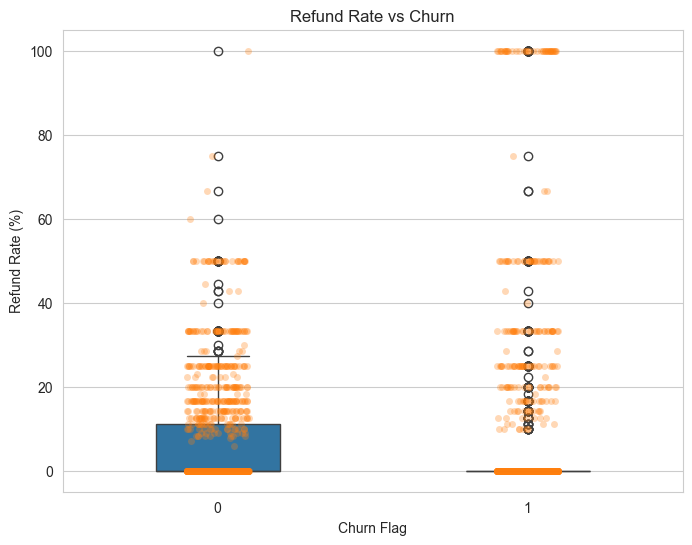

In [80]:
# Refund Rate vs Churn Analysis

# Step 1: Calculate refund rate per customer
orders_source = orders_refund.copy() if 'orders_refund' in globals() else orders.copy()

if 'is_refunded' not in orders_source.columns:
    if 'returned' in orders_source.columns:
        orders_source['is_refunded'] = (orders_source['returned'] > 0).astype(int)
    else:
        raise KeyError("Column not found: is_refunded")

refund_rate = (
    orders_source.groupby('customer_id')['is_refunded']
    .mean()
    .reset_index()
)

# Rename column for clarity
refund_rate.rename(
    columns={'is_refunded': 'refund_rate'},
    inplace=True
)

# Convert to percentage
refund_rate['refund_rate'] = (
    refund_rate['refund_rate'] * 100
)

# Step 2: Merge with churn labels
refund_churn = refund_rate.merge(
    churn_labels,
    on='customer_id',
    how='inner'
)

# Step 3: Summary table
summary_table = (
    refund_churn.groupby('churn_flag')['refund_rate']
    .agg(['mean', 'median', 'count'])
    .reset_index()
)

print(summary_table)

# Step 4: Visualization
plt.figure(figsize=(8,6))

sns.boxplot(
    data=refund_churn,
    x='churn_flag',
    y='refund_rate',
    width=0.4
)

sns.stripplot(
    data=refund_churn,
    x='churn_flag',
    y='refund_rate',
    alpha=0.3,
    jitter=True
)

plt.title("Refund Rate vs Churn")
plt.xlabel("Churn Flag")
plt.ylabel("Refund Rate (%)")

plt.show()

The refund-rate distribution indicates that while most customers exhibit little or no refund behavior, churned customers contain a higher concentration of elevated refund rates. This suggests that repeated refunds may reflect dissatisfaction with product quality, fulfillment reliability, or customer expectations. However, since many retained customers also exhibit refund activity, refunds alone are unlikely to fully explain churn behavior. Refund patterns should therefore be analyzed together with engagement, delivery performance, and support interactions to identify high-risk customer segments more accurately.
1. Refund-heavy customers appear in both groups

Refunds alone do not guarantee churn.

Some active customers continue purchasing despite refunds, possibly because:

support resolves issues,
loyalty remains strong,
refunds are part of normal behavior.
2. High refund percentages are common among churned users

Customers with:

20%–50% refund rates
are strongly represented in the churned segment.

3. Median refund rate is near zero

The median line is close to 0 for both groups, meaning:

most customers rarely request refunds,
churn is likely driven by a smaller high-risk subset.

This is important because the churn problem may be concentrated rather than universal.